# 01 — Data and Features

**Question of the project:** can simple, well-known stock characteristics predict which stocks will do better than others **next month**, when tested honestly on data the model has never seen?

This notebook builds the dataset: 52 large-cap US stocks across 7 sectors, 2010–2026, and 8 features computed at each month-end using **only past data**.

All logic lives in `src/data.py` and `src/features.py`.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import UNIVERSE, TICKERS
from src.data import load_prices
from src.features import build_panel, FEATURES, FEATURE_DESCRIPTIONS

pd.Series(UNIVERSE).value_counts().rename("stocks per sector")

Tech                 12
Consumer              9
Financials            8
Health                8
Industrials           7
Energy                4
Utilities/Telecom     4
Name: stocks per sector, dtype: int64

## 1. Prices and volumes
The first run downloads from Yahoo Finance (about a minute) and caches to `data/raw/`.

In [2]:
close, volume = load_prices()
print(close.shape, close.index[0].date(), "to", close.index[-1].date())
print("Missing prices per stock (max):", close.isna().sum().max())
close.tail(3)

(4190, 53) 2010-01-04 to 2026-08-31
Missing prices per stock (max): 0


Ticker,AAPL,MSFT,GOOGL,AMZN,NVDA,ORCL,CSCO,INTC,IBM,ADBE,...,LMT,XOM,CVX,COP,SLB,NEE,DUK,VZ,T,SPY
Date,,,,,,,,,,,,,,,,,,,,,
2026-08-27,314.579987,505.059998,340.431183,256.260010,227.725174,151.940002,112.150002,92.089996,238.789993,289.149994,...,562.411377,156.440002,199.770004,129.520004,54.726044,82.847000,120.839996,49.430000,25.430000,769.189941
2026-08-28,319.700012,513.530029,346.367371,266.429993,217.306839,150.850006,109.930000,89.470001,235.589996,291.519989,...,560.383850,156.710007,201.860001,130.350006,57.034073,81.839996,120.250000,50.099998,26.010000,767.444275
2026-08-31,316.850006,507.290009,339.132019,259.769989,220.533234,149.119995,110.489998,89.510002,233.869995,292.790009,...,557.779968,160.949997,206.139999,132.490005,59.789768,82.339996,119.910004,50.020000,25.889999,765.149963


## 2. The features
Each one is a classic, published predictor of the cross-section of stock returns.

In [3]:
pd.Series(FEATURE_DESCRIPTIONS, name="definition").to_frame()

,definition
mom_12_1,Momentum: return from 12 months ago to 1 month...
rev_1m,Short-term reversal: return over the last month
vol_1m,"Volatility: annualized std of daily returns, l..."
vol_3m,"Volatility: annualized std of daily returns, l..."
log_dollar_vol,"Liquidity: log of average daily dollar volume,..."
amihud,Illiquidity (Amihud): log of average |return| ...
beta_1y,"Market beta vs SPY, last 252 days (risk exposure)"
idio_vol,Idiosyncratic volatility: residual vol after r...


## 3. Build the monthly panel
One row per (month-end, stock). The target is the **next month's return**, measured relative to the average stock that month (`fwd_ret_xs`), so we predict *which stocks beat the others*, not whether the market goes up.

Each month the features are also converted to **ranks between −0.5 and +0.5** (`*_r` columns): this removes outliers and makes 2012 comparable to 2022.

In [4]:
panel = build_panel(close, volume)
panel.to_pickle("../data/processed/panel.pkl")
print(panel.shape)
print("Months:", panel.index.get_level_values("date").nunique(),
      "| first:", panel.index.get_level_values("date").min().date(),
      "| last:", panel.index.get_level_values("date").max().date())
panel.head()

(9776, 18)
Months: 188 | first: 2011-01-31 | last: 2026-08-31


mom_12_1    rev_1m    vol_1m    vol_3m  log_dollar_vol  \
date       ticker                                                           
2011-01-31 AAPL    0.662096  0.048384  0.224379  0.189142       22.392779   
           ABT    -0.084783 -0.041849  0.146211  0.126203       19.787578   
           ADBE   -0.058805  0.081125  0.252604  0.264544       19.204976   
           AMGN   -0.054326 -0.008103  0.161725  0.180932       19.223561   
           AMZN    0.537394 -0.071737  0.376197  0.313834       20.728686   

                     amihud   beta_1y  idio_vol   fwd_ret  mom_12_1_r  \
date       ticker                                                       
2011-01-31 AAPL   -6.094038  1.007738  0.142561  0.040935    0.480769   
           ABT    -4.051394  0.506777  0.116953  0.065101   -0.403846   
           ADBE   -2.824225  1.084181  0.220675  0.043873   -0.384615   
           AMGN   -3.308723  0.750923  0.168112 -0.068083   -0.365385   
           AMZN   -4.251315  1.206351  0.264420  0.021516    0.461538   

                   rev_1m_r  vol_1m_r  vol_3m_r  log_dollar_vol_r  amihud_r  \
date       ticker                                                             
2011-01-31 AAPL    0.192308  0.211538  0.038462          0.500000 -0.480769   
           ABT    -0.423077 -0.307692 -0.326923          0.019231 -0.038462   
           ADBE    0.365385  0.288462  0.365385         -0.269231  0.461538   
           AMGN   -0.211538 -0.134615  0.000000         -0.230769  0.230769   
           AMZN   -0.461538  0.480769  0.442308          0.365385 -0.153846   

                   beta_1y_r  idio_vol_r  fwd_ret_xs  
date       ticker                                     
2011-01-31 AAPL     0.096154   -0.076923    0.014933  
           ABT     -0.403846   -0.230769    0.039099  
           ADBE     0.211538    0.384615    0.017871  
           AMGN    -0.173077    0.115385   -0.094085  
           AMZN     0.250000    0.442308   -0.004486

In [5]:
panel[FEATURES + ["fwd_ret"]].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
mom_12_1,9776.0,0.152,0.281,-0.654,-0.006,0.124,0.275,5.245
rev_1m,9776.0,0.013,0.075,-0.515,-0.028,0.013,0.054,1.141
vol_1m,9776.0,0.239,0.138,0.039,0.154,0.206,0.284,2.045
vol_3m,9776.0,0.246,0.121,0.064,0.170,0.219,0.286,1.414
log_dollar_vol,9776.0,20.316,0.923,17.843,19.739,20.209,20.746,24.702
amihud,9776.0,-4.194,0.856,-7.901,-4.616,-4.155,-3.658,-1.534
beta_1y,9776.0,0.922,0.398,-0.543,0.660,0.931,1.161,2.888
idio_vol,9776.0,0.191,0.086,0.049,0.133,0.173,0.227,0.974
fwd_ret,9724.0,0.013,0.074,-0.502,-0.029,0.012,0.053,1.141


## 4. How related are the features?
High correlation between features means they carry overlapping information (e.g. the two volatility measures).

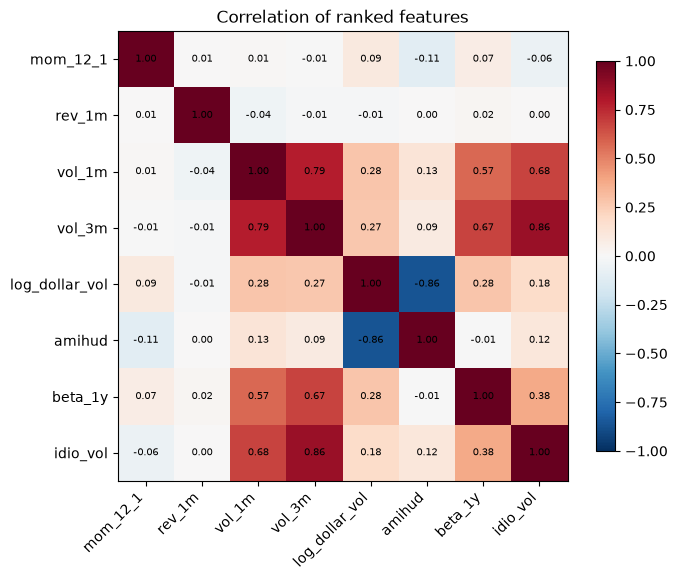

In [6]:
corr = panel[[f + "_r" for f in FEATURES]].corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURES))); ax.set_xticklabels(FEATURES, rotation=45, ha="right")
ax.set_yticks(range(len(FEATURES))); ax.set_yticklabels(FEATURES)
for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlation of ranked features")
plt.tight_layout(); plt.show()

## 5. Key numbers (text summary)

In [7]:
print("Stocks:", panel.index.get_level_values("ticker").nunique())
print("Rows:", len(panel), "| months:", panel.index.get_level_values("date").nunique())
print("\nFeature summary:")
print(panel[FEATURES + ["fwd_ret"]].describe().T[["mean", "std", "min", "max"]].round(3).to_string())
print("\nMost correlated feature pairs:")
pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), 1)).stack().sort_values(key=abs, ascending=False)
print(pairs.head(5).round(2).to_string())

Stocks: 52
Rows: 9776 | months: 188

Feature summary:
                  mean    std     min     max
mom_12_1         0.152  0.281  -0.654   5.245
rev_1m           0.013  0.075  -0.515   1.141
vol_1m           0.239  0.138   0.039   2.045
vol_3m           0.246  0.121   0.064   1.414
log_dollar_vol  20.316  0.923  17.843  24.702
amihud          -4.194  0.856  -7.901  -1.534
beta_1y          0.922  0.398  -0.543   2.888
idio_vol         0.191  0.086   0.049   0.974
fwd_ret          0.013  0.074  -0.502   1.141

Most correlated feature pairs:
log_dollar_vol_r  amihud_r     -0.86
vol_3m_r          idio_vol_r    0.86
vol_1m_r          vol_3m_r      0.79
                  idio_vol_r    0.68
vol_3m_r          beta_1y_r     0.67


## Takeaways

- **Dataset:** 52 large-cap stocks × 188 months = 9,776 stock-months (2010–2026); the last month has no next-month return yet.
- **Two families of features:** momentum and reversal are nearly uncorrelated with everything else (|corr| ≤ 0.11), while the risk features cluster together (vol_3m–idio_vol 0.86, vol_1m–vol_3m 0.79, vol_3m–beta 0.67).
- **Redundant pairs:** liquidity and Amihud illiquidity (−0.86), 3-month and idiosyncratic volatility (0.86). Models must handle collinearity: Ridge's penalty and shallow trees do.
- **Heavy tails:** raw momentum reaches +525% and a monthly return +114%. Monthly cross-sectional ranks keep such outliers from dominating.